# AI for Women's Health Imaging: BreastMNIST Ultrasound Classification

This notebook runs a reproducible research-style experiment on **BreastMNIST**, a public breast ultrasound benchmark from MedMNIST v2. The workflow trains classical baselines and repeated CNN runs, selects operating thresholds using validation predictions, evaluates the held-out test split, saves figures/tables/checkpoints, and writes an analysis report from the actual outputs.

**Run all cells.** The project folders fill automatically:

- `figures/`: saved plots and Grad-CAM overlays
- `results/`: metrics, predictions, model checkpoints, summaries, threshold sweeps
- `analysis/`: generated experiment write-up

In [1]:
# Colab setup. This installs only the packages needed for the project.
import sys
import subprocess
import importlib.util

package_specs = [
    "medmnist>=3.0.2",
    "scikit-learn>=1.3",
    "pandas>=2.0",
    "matplotlib>=3.7",
    "tabulate>=0.9",
]
module_checks = {
    "medmnist": "medmnist",
    "scikit-learn": "sklearn",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "tabulate": "tabulate",
}
missing = [name for name, module in module_checks.items() if importlib.util.find_spec(module) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *package_specs])
else:
    print("All required third-party packages are already available.")

Installing missing packages: ['medmnist']


In [2]:
# Resolve the project root in Google Colab, Google Drive, and local notebook execution.
# This prevents `ModuleNotFoundError: No module named breast_ai` when Colab starts outside the repo folder.
from pathlib import Path
import os
import sys
import subprocess


def find_project_root() -> Path:
    starts = [Path.cwd(), Path.cwd().parent]
    if Path("/content").exists():
        starts.append(Path("/content"))
    if Path("/content/drive/MyDrive").exists():
        starts.append(Path("/content/drive/MyDrive"))

    for start in starts:
        candidate = start / "src" / "breast_ai"
        if candidate.exists():
            return candidate.parents[1]

    try:
        import google.colab  # type: ignore
        from google.colab import drive  # type: ignore
        if not Path("/content/drive/MyDrive").exists():
            print("Mounting Google Drive so the repository folder can be located...")
            drive.mount("/content/drive")
    except Exception:
        pass

    search_roots = [Path("/content"), Path("/content/drive/MyDrive")]
    for base in search_roots:
        if base.exists():
            matches = list(base.glob("**/src/breast_ai"))
            if matches:
                matches = sorted(matches, key=lambda p: len(str(p)))
                return matches[0].parents[1]

    raise FileNotFoundError(
        "Could not find the repository package folder `src/breast_ai`. "
        "Upload or unzip the full repository folder, then run this notebook again."
    )


PROJECT_ROOT = find_project_root().resolve()
os.chdir(PROJECT_ROOT)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

if (PROJECT_ROOT / "pyproject.toml").exists():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(PROJECT_ROOT)])

for folder in ["data", "figures", "results", "results/models", "results/tables", "analysis"]:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Package source path: {SRC_PATH}")
print("Writable artifact folders are ready:")
for folder in ["figures", "results", "analysis"]:
    print(" -", PROJECT_ROOT / folder)

import breast_ai
print("Imported breast_ai from:", Path(breast_ai.__file__).resolve())

Mounting Google Drive so the repository folder can be located...
Mounted at /content/drive
Project root: /content/drive/MyDrive/repo_polished
Package source path: /content/drive/MyDrive/repo_polished/src
Writable artifact folders are ready:
 - /content/drive/MyDrive/repo_polished/figures
 - /content/drive/MyDrive/repo_polished/results
 - /content/drive/MyDrive/repo_polished/analysis
Imported breast_ai from: /content/drive/MyDrive/repo_polished/src/breast_ai/__init__.py


## Dataset citation and study framing

The dataset is **BreastMNIST** from **MedMNIST v2**. BreastMNIST is based on a breast ultrasound image dataset containing normal, benign, and malignant cases. In MedMNIST v2, the source images are resized to 1×28×28 and the task is simplified into binary classification by combining normal and benign into non-malignant against malignant.

**Citations used in this project**

- Yang J, Shi R, Wei D, Liu Z, Zhao L, Ke B, Pfister H, Ni B. *MedMNIST v2-A large-scale lightweight benchmark for 2D and 3D biomedical image classification*. Scientific Data. 2023.
- Yang J, Shi R, Ni B. *MedMNIST Classification Decathlon: A Lightweight AutoML Benchmark for Medical Image Analysis*. ISBI. 2021.
- Al-Dhabyani W, Gomaa M, Khaled H, Fahmy A. *Dataset of breast ultrasound images*. Data in Brief. 2020.

This is a benchmark research prototype, not a clinical diagnostic system.

In [3]:
# Imports and configuration
import json
import time
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

from breast_ai.config import ExperimentConfig
from breast_ai.data import make_dataloaders, summarize_label_distribution
from breast_ai.experiment import run_full_experiment
from breast_ai.utils import resolve_device, set_seed, save_json

config = ExperimentConfig(
    seeds=[13, 42, 101],
    seed=42,
    batch_size=64,
    epochs=200,
    learning_rate=1e-3,
    weight_decay=1e-4,
    patience=30,
    min_delta=1e-4,
    sensitivity_floor=0.90,
    threshold=0.50,
    use_class_weights=True,
    bootstrap_iterations=1000,
    project_root=str(PROJECT_ROOT),
)
set_seed(config.seed)
device = resolve_device(config.device)

print("Experiment configuration:")
print(json.dumps(config.to_dict(), indent=2))
print(f"Resolved compute device: {device}")
save_json(config.to_dict(), PROJECT_ROOT / "results" / "config.json")

Experiment configuration:
{
  "seeds": [
    13,
    42,
    101
  ],
  "seed": 42,
  "batch_size": 64,
  "epochs": 200,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "patience": 30,
  "min_delta": 0.0001,
  "threshold": 0.5,
  "sensitivity_floor": 0.9,
  "num_workers": 0,
  "device": "auto",
  "project_root": "/content/drive/MyDrive/repo_polished",
  "dataset_name": "breastmnist",
  "image_size": 28,
  "use_class_weights": true,
  "bootstrap_iterations": 1000
}
Resolved compute device: cpu


In [4]:
# Download/load BreastMNIST and print split summaries before training.
paths = config.paths()
bundle = make_dataloaders(
    root=str(paths["data"]),
    batch_size=config.batch_size,
    num_workers=config.num_workers,
    seed=config.seed,
    download=True,
)

label_summary = {
    "train": summarize_label_distribution(bundle.train_loader, bundle.class_names),
    "val": summarize_label_distribution(bundle.val_loader, bundle.class_names),
    "test": summarize_label_distribution(bundle.test_loader, bundle.class_names),
}

dataset_summary = {
    "dataset_sizes": bundle.dataset_sizes,
    "class_names": list(bundle.class_names),
    "label_distribution": label_summary,
}
print("Dataset summary:")
print(json.dumps(dataset_summary, indent=2))
save_json(dataset_summary, PROJECT_ROOT / "results" / "dataset_summary_preview.json")

Dataset summary:
{
  "dataset_sizes": {
    "train": 546,
    "val": 78,
    "test": 156
  },
  "class_names": [
    "non_malignant",
    "malignant"
  ],
  "label_distribution": {
    "train": {
      "non_malignant": 147,
      "malignant": 399
    },
    "val": {
      "non_malignant": 21,
      "malignant": 57
    },
    "test": {
      "non_malignant": 42,
      "malignant": 114
    }
  }
}


## Full experiment run

This cell trains the full benchmark suite:

- class-balanced logistic regression baseline
- class-balanced random forest baseline
- repeated `tiny_cnn`, `enhanced_cnn`, and `residual_cnn` runs over three random seeds
- validation-only threshold selection with a sensitivity floor
- test-set reporting after the threshold is locked

The epoch budget is intentionally high. Early stopping decides when each CNN is finished.

In [5]:
start = time.perf_counter()
experiment = run_full_experiment(config, model_names=["tiny_cnn", "enhanced_cnn", "residual_cnn"])
elapsed = time.perf_counter() - start

metrics = experiment["metrics"]
metrics_summary = experiment["metrics_summary"]
summary = experiment["summary"]

print(f"Experiment finished in {elapsed / 60:.2f} minutes.")
print("Best aggregate model:", summary["best_model_by_mean_auc"])
print("Best operating threshold for representative visual run:", summary["best_operating_threshold"])

print("\nRepeated-run model summary:")
display(metrics_summary)

print("\nPer-run metrics:")
display(metrics)

print("\nSaved summary JSON:", PROJECT_ROOT / "results" / "experiment_summary.json")
print("Saved per-run metrics CSV:", summary["metrics_path"])
print("Saved model-summary CSV:", summary["metrics_summary_path"])
print("Saved test predictions CSV:", summary["predictions_path"])
print("Saved validation predictions CSV:", summary["validation_predictions_path"])
print("Generated analysis report:", summary["analysis_report"])
print("\nSaved figures:")
for fig_path in summary["figures"]:
    print(" -", fig_path)


Experiment finished in 21.38 minutes.
Best aggregate model: enhanced_cnn
Best operating threshold for representative visual run: 0.31

Repeated-run model summary:


,model,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_min,balanced_accuracy_max,roc_auc_mean,...,threshold_min,threshold_max,best_epoch_mean,best_epoch_std,best_epoch_min,best_epoch_max,stopped_epoch_mean,stopped_epoch_std,stopped_epoch_min,stopped_epoch_max
0,enhanced_cnn,0.841880,0.019584,0.820513,0.858974,0.834169,0.013516,0.824561,0.849624,0.902395,...,0.31,0.61,38.333333,4.509250,34.0,43.0,68.333333,4.509250,64.0,73.0
3,residual_cnn,0.829060,0.028905,0.801282,0.858974,0.827903,0.023514,0.803885,0.850877,0.893553,...,0.13,0.58,39.000000,7.211103,33.0,47.0,69.000000,7.211103,63.0,77.0
4,tiny_cnn,0.831197,0.018505,0.820513,0.852564,0.794277,0.034114,0.764411,0.831454,0.876462,...,0.33,0.54,49.333333,1.527525,48.0,51.0,79.333333,1.527525,78.0,81.0
2,random_forest,0.816239,0.007402,0.807692,0.820513,0.728906,0.009405,0.718045,0.734336,0.817808,...,0.58,0.58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,logistic_regression,0.754274,0.009792,0.743590,0.762821,0.678989,0.036267,0.645363,0.717419,0.764063,...,0.19,0.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Per-run metrics:


,accuracy,balanced_accuracy,roc_auc,average_precision,precision,recall_sensitivity,specificity,npv,f1,brier_score,...,tp,auc_ci_low,auc_ci_high,model,seed,best_epoch,stopped_epoch,best_val_loss,threshold_rule,model_family
9,0.858974,0.850877,0.914578,0.966546,0.933962,0.868421,0.833333,0.700000,0.900000,0.164503,...,99,0.862080,0.957978,residual_cnn,42,47.0,77.0,0.323319,max_specificity_given_sensitivity_at_least_0.90,cnn
3,0.846154,0.849624,0.909357,0.950964,0.941176,0.842105,0.857143,0.666667,0.888889,0.136532,...,96,0.848106,0.958912,enhanced_cnn,13,38.0,68.0,0.245668,max_specificity_given_sensitivity_at_least_0.90,cnn
8,0.858974,0.828321,0.903718,0.951876,0.910714,0.894737,0.761905,0.727273,0.902655,0.116962,...,102,0.836031,0.954804,enhanced_cnn,42,34.0,64.0,0.262183,max_specificity_given_sensitivity_at_least_0.90,cnn
13,0.820513,0.824561,0.894110,0.951781,0.930000,0.815789,0.833333,0.625000,0.869159,0.128794,...,93,0.835813,0.946188,enhanced_cnn,101,43.0,73.0,0.298281,max_specificity_given_sensitivity_at_least_0.90,cnn
14,0.826923,0.828947,0.891604,0.944996,0.930693,0.824561,0.833333,0.636364,0.874419,0.145581,...,94,0.827310,0.945441,residual_cnn,101,33.0,63.0,0.295308,max_specificity_given_sensitivity_at_least_0.90,cnn
7,0.852564,0.831454,0.886278,0.940435,0.917431,0.877193,0.785714,0.702128,0.896861,0.121470,...,100,0.813682,0.945290,tiny_cnn,42,51.0,81.0,0.265770,max_specificity_given_sensitivity_at_least_0.90,cnn
12,0.820513,0.764411,0.880326,0.945662,0.870690,0.885965,0.642857,0.675000,0.878261,0.126733,...,101,0.810386,0.936186,tiny_cnn,101,48.0,78.0,0.233532,max_specificity_given_sensitivity_at_least_0.90,cnn
4,0.801282,0.803885,0.874478,0.947989,0.919192,0.798246,0.809524,0.596491,0.854460,0.151858,...,91,0.811025,0.931549,residual_cnn,13,37.0,67.0,0.332568,max_specificity_given_sensitivity_at_least_0.90,cnn
2,0.820513,0.786967,0.862782,0.938743,0.890909,0.859649,0.714286,0.652174,0.875000,0.159595,...,98,0.790984,0.924901,tiny_cnn,13,49.0,79.0,0.338800,max_specificity_given_sensitivity_at_least_0.90,cnn
1,0.820513,0.734336,0.837928,0.923386,0.846774,0.921053,0.547619,0.718750,0.882353,0.136782,...,105,0.758459,0.909299,random_forest,13,NaN,NaN,NaN,max_specificity_given_sensitivity_at_least_0.90,classical_ml



Saved summary JSON: /content/drive/MyDrive/repo_polished/results/experiment_summary.json
Saved per-run metrics CSV: /content/drive/MyDrive/repo_polished/results/metrics_by_run.csv
Saved model-summary CSV: /content/drive/MyDrive/repo_polished/results/metrics_summary_by_model.csv
Saved test predictions CSV: /content/drive/MyDrive/repo_polished/results/predictions_test.csv
Saved validation predictions CSV: /content/drive/MyDrive/repo_polished/results/predictions_validation.csv
Generated analysis report: /content/drive/MyDrive/repo_polished/analysis/experiment_report.md

Saved figures:
 - /content/drive/MyDrive/repo_polished/figures/dataset_examples.png
 - /content/drive/MyDrive/repo_polished/figures/training_curves_tiny_cnn_seed13.png
 - /content/drive/MyDrive/repo_polished/figures/training_curves_enhanced_cnn_seed13.png
 - /content/drive/MyDrive/repo_polished/figures/training_curves_residual_cnn_seed13.png
 - /content/drive/MyDrive/repo_polished/figures/training_curves_tiny_cnn_seed42.p

## Visual results

The following cells print saved figures inside the notebook and leave the same files in `figures/` for GitHub.

### dataset_examples.png

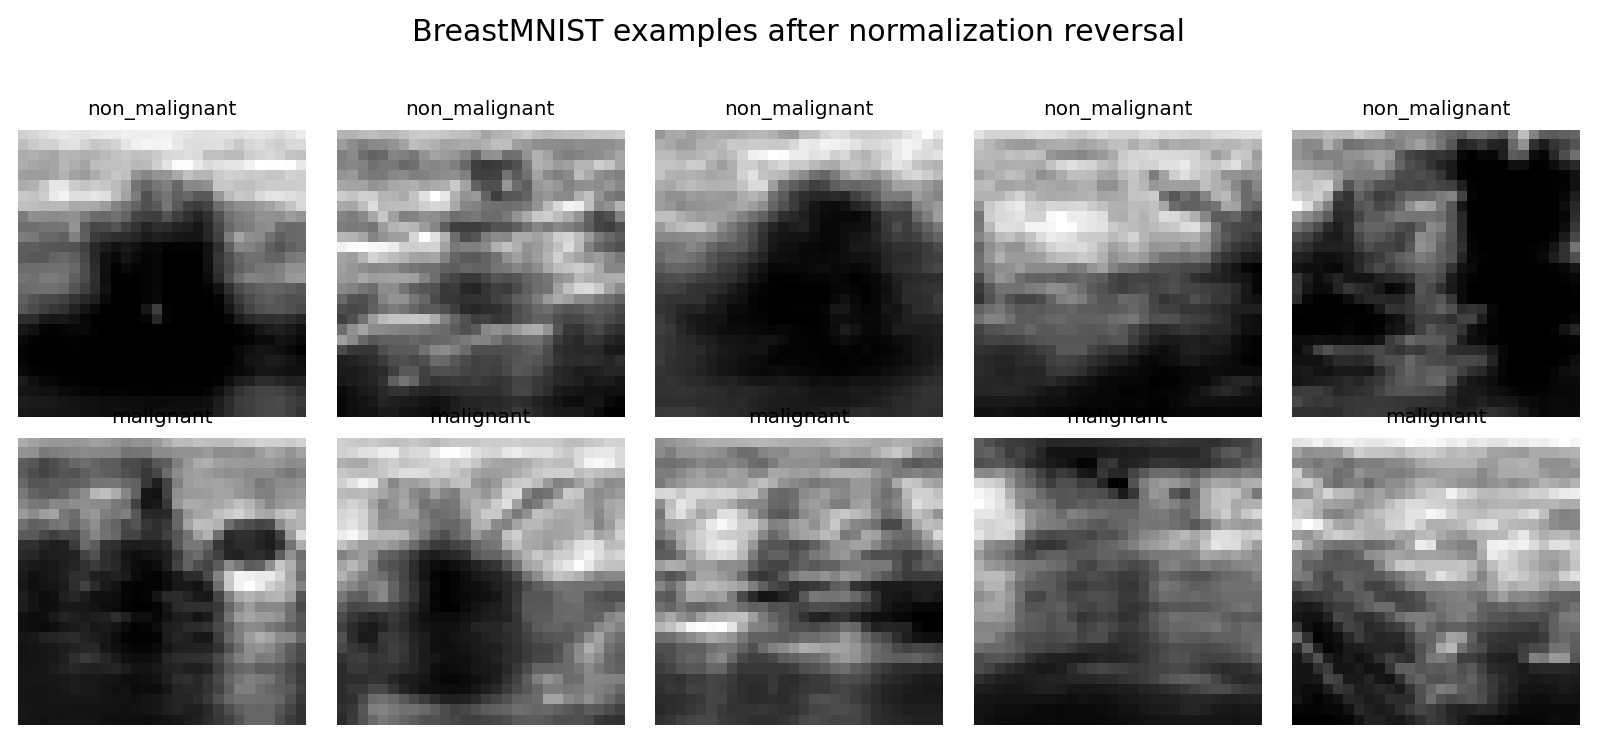

### training_curves_tiny_cnn_seed13.png

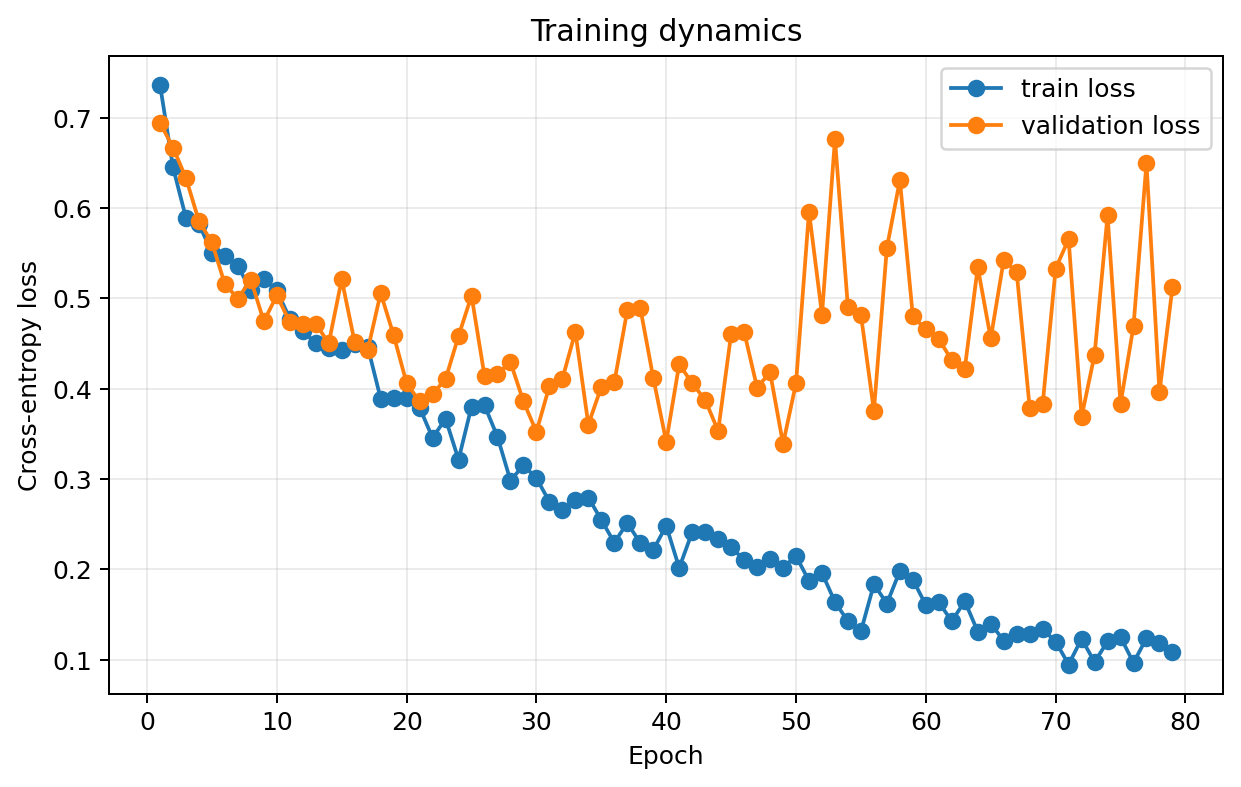

### training_curves_enhanced_cnn_seed13.png

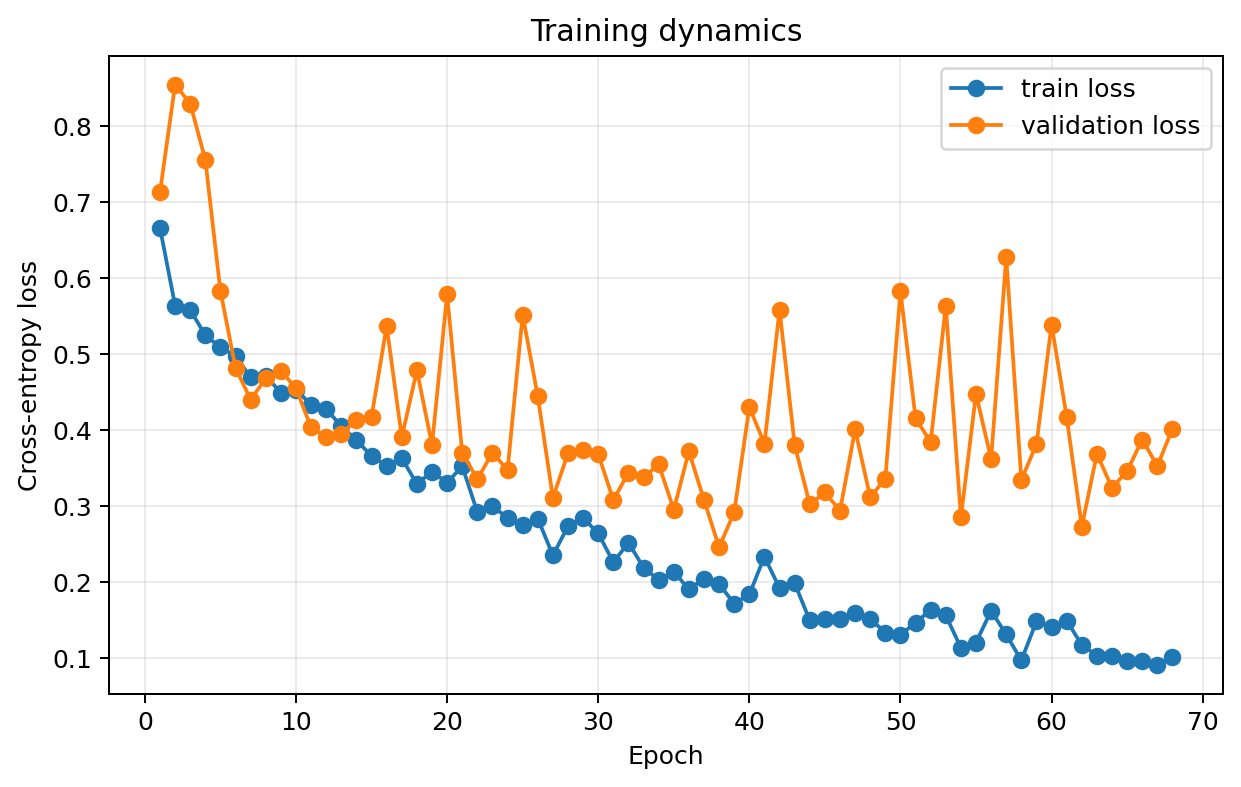

### training_curves_residual_cnn_seed13.png

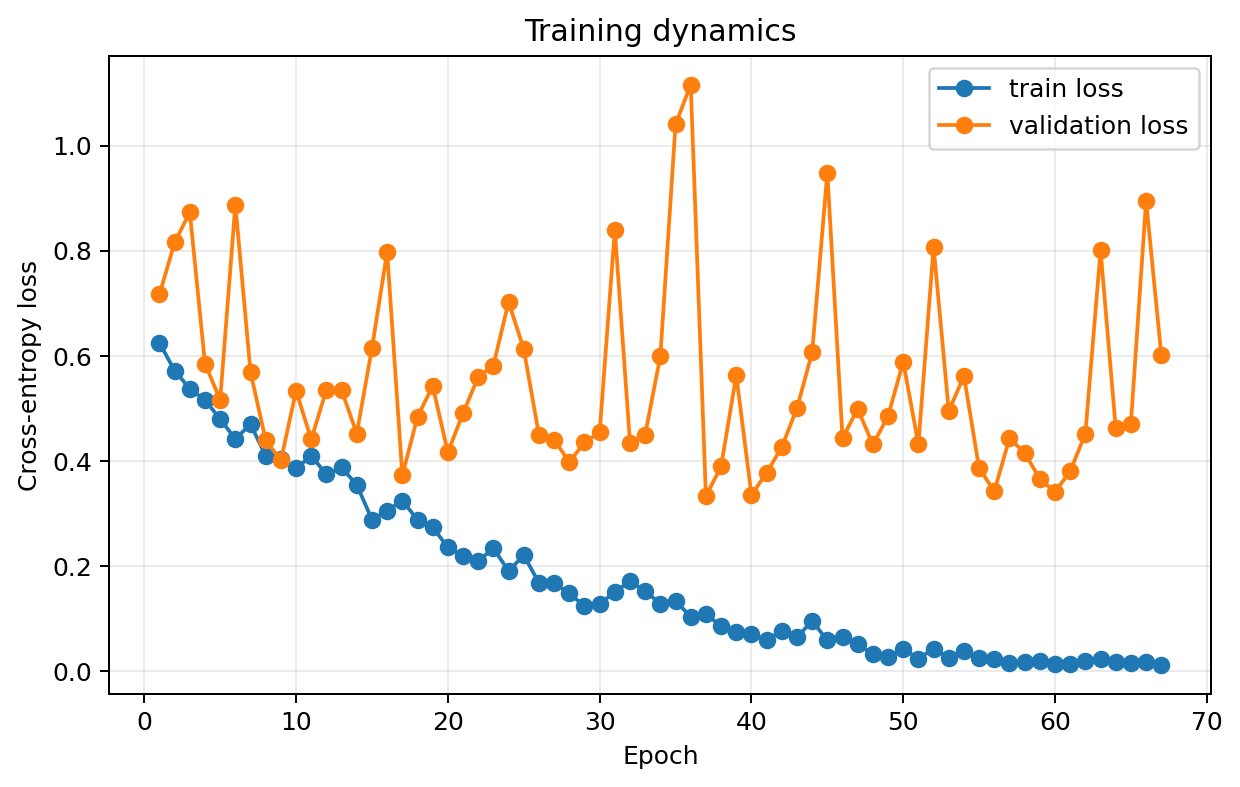

### training_curves_tiny_cnn_seed42.png

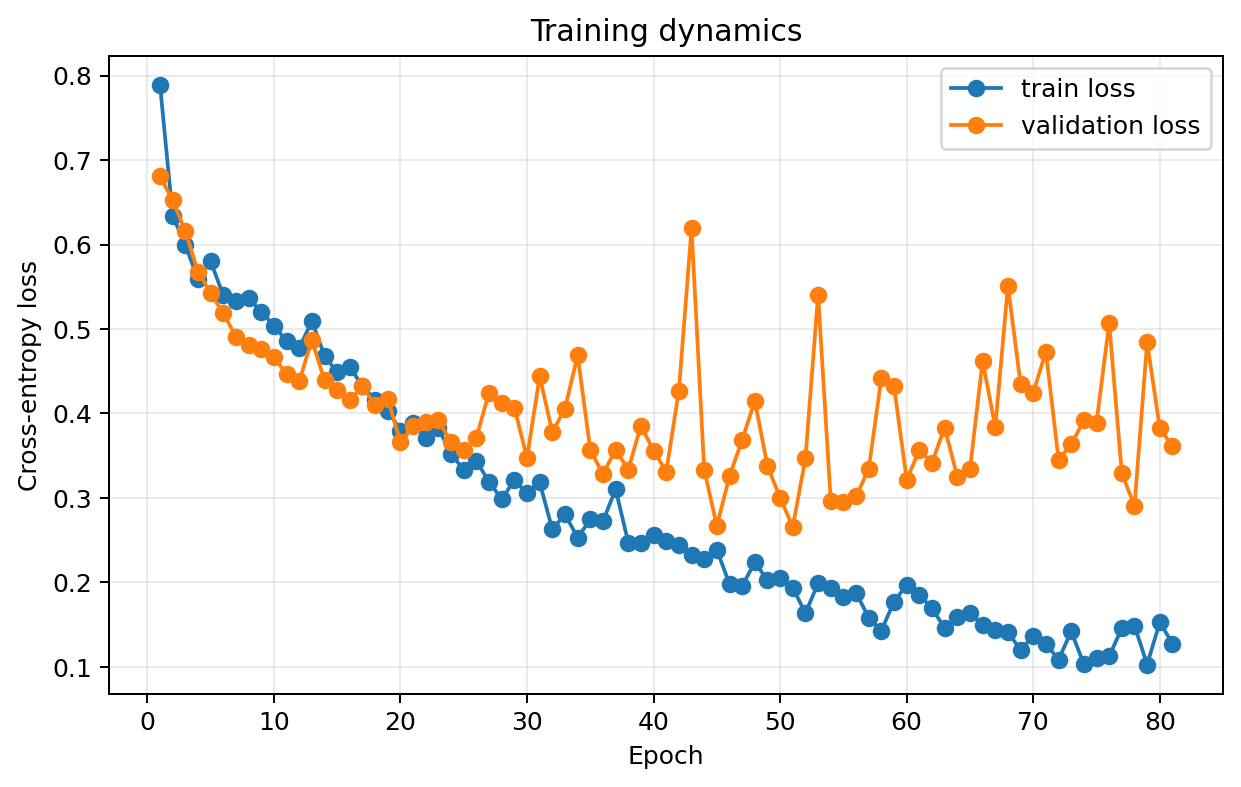

### training_curves_enhanced_cnn_seed42.png

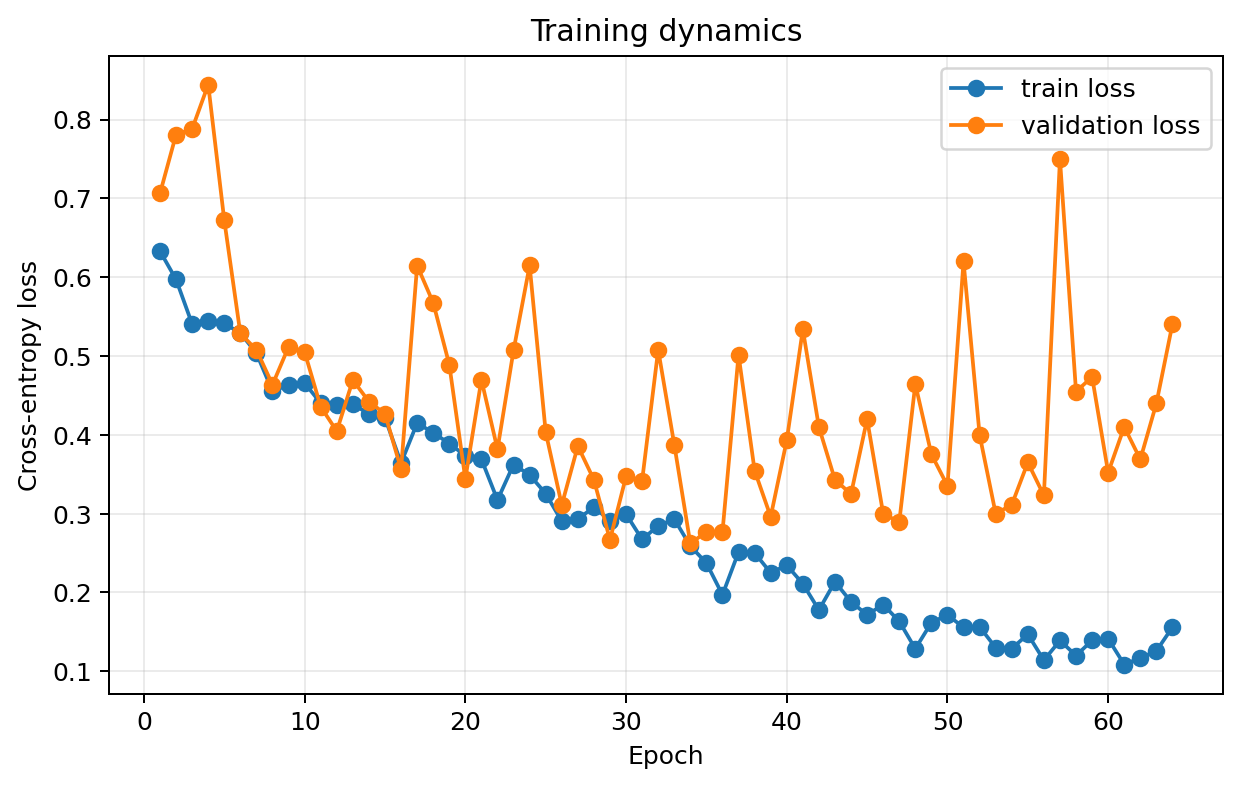

### training_curves_residual_cnn_seed42.png

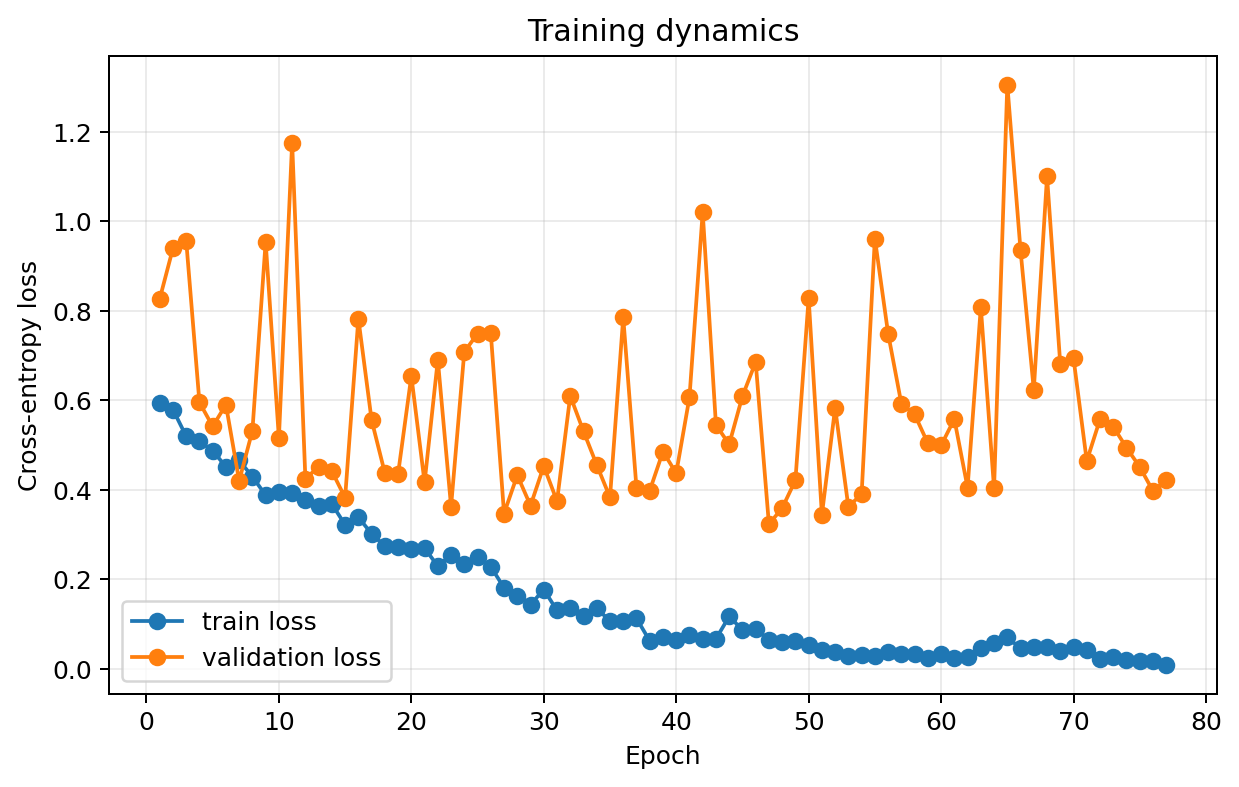

### training_curves_tiny_cnn_seed101.png

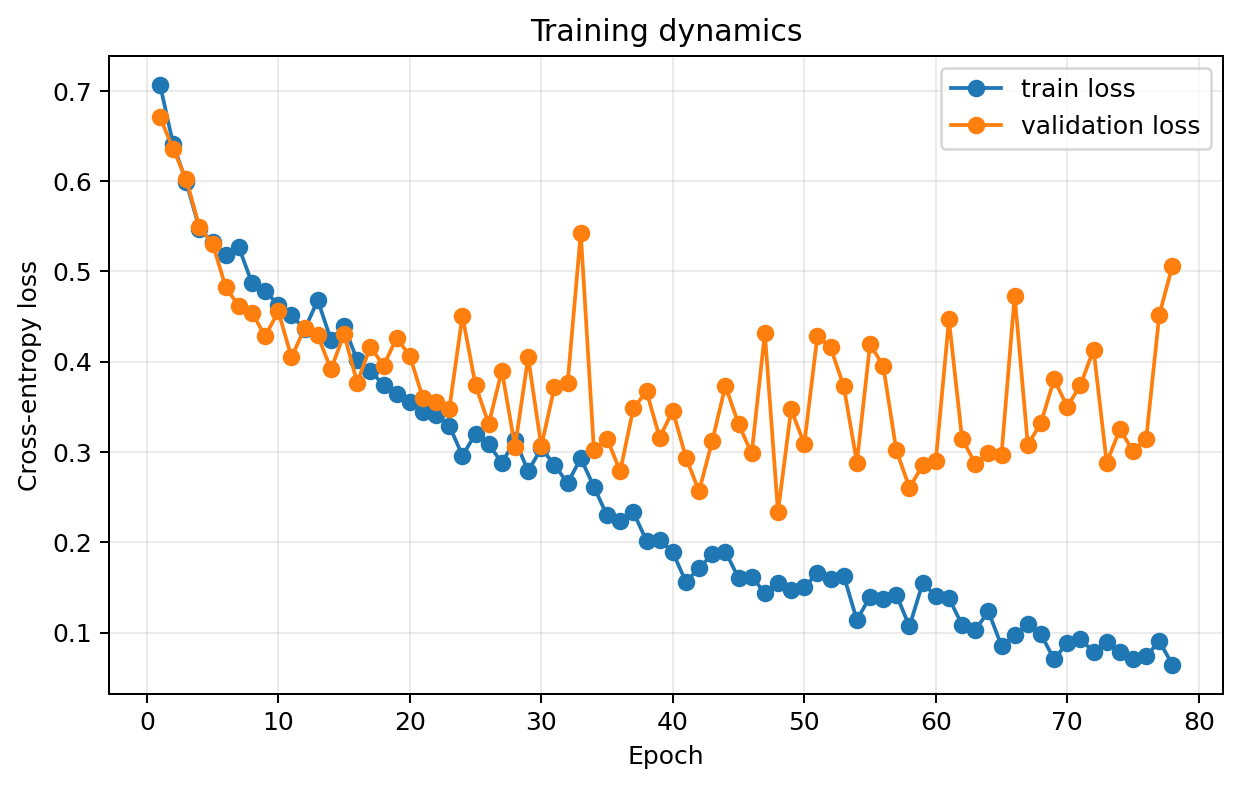

### training_curves_enhanced_cnn_seed101.png

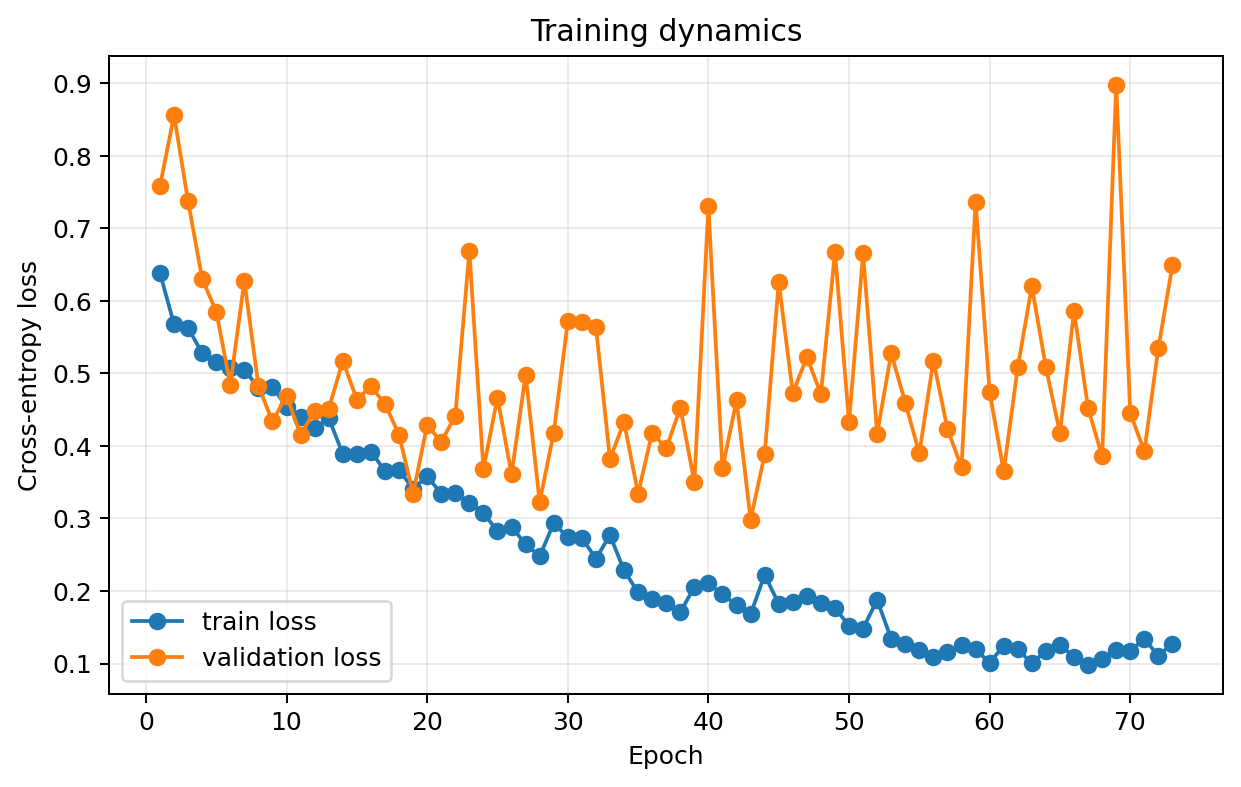

### training_curves_residual_cnn_seed101.png

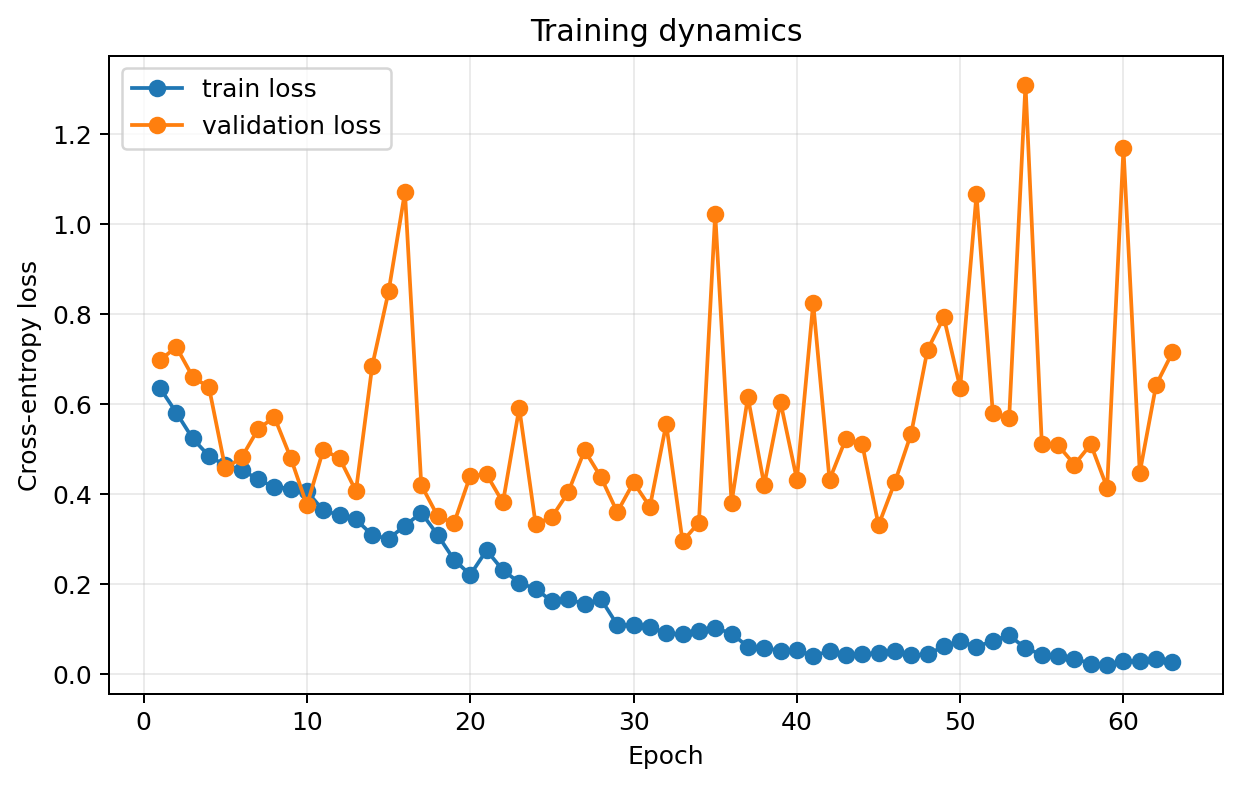

### experiment_metric_table.png

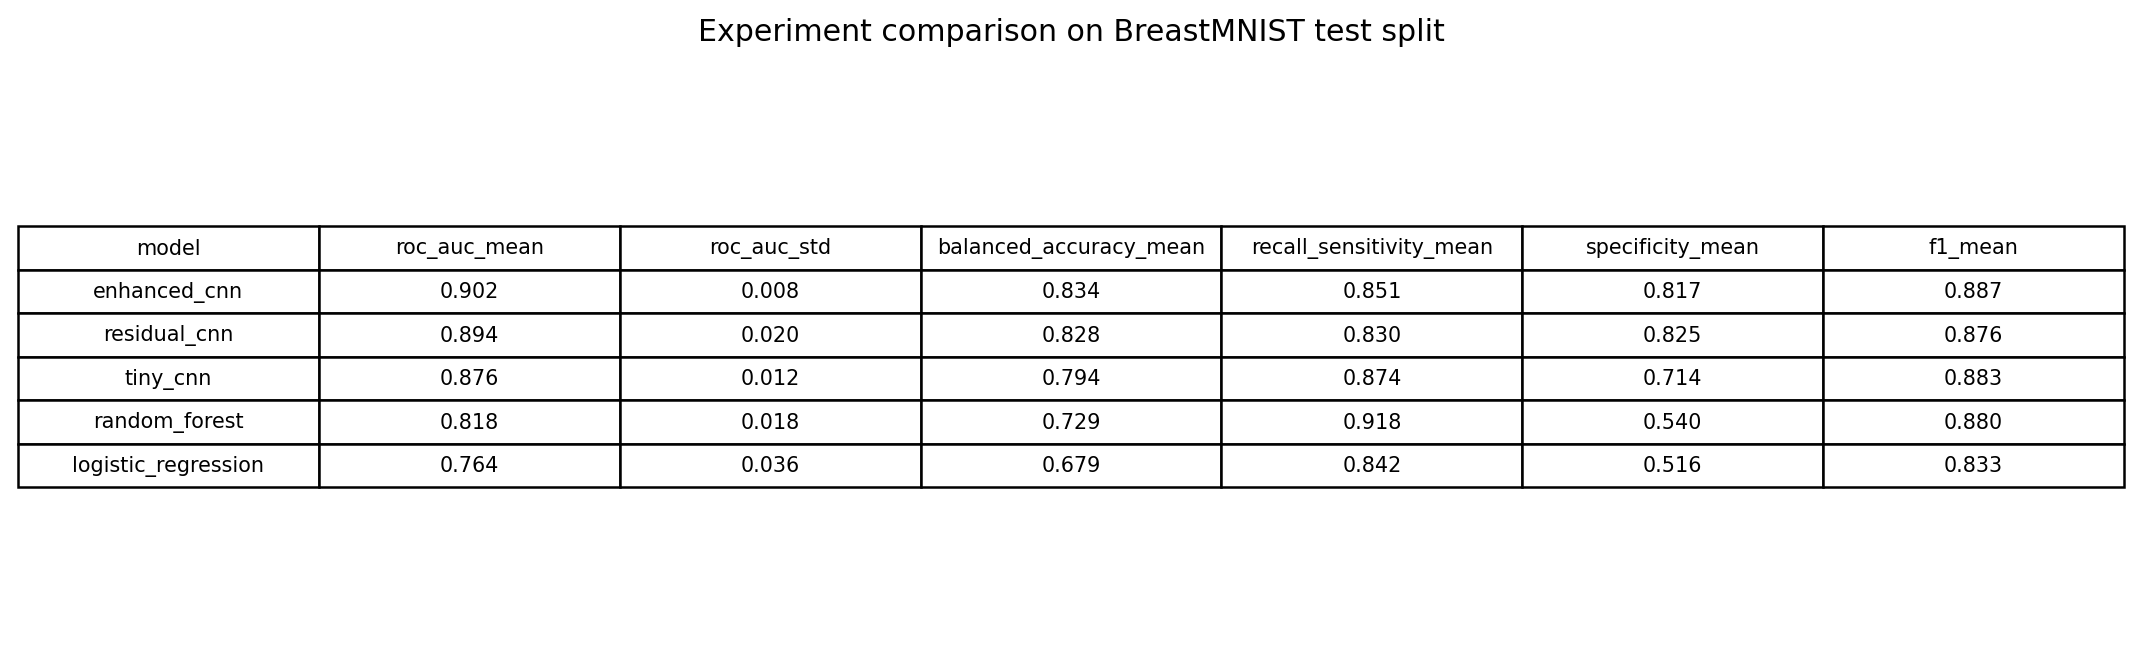

### repeated_metric_summary.png

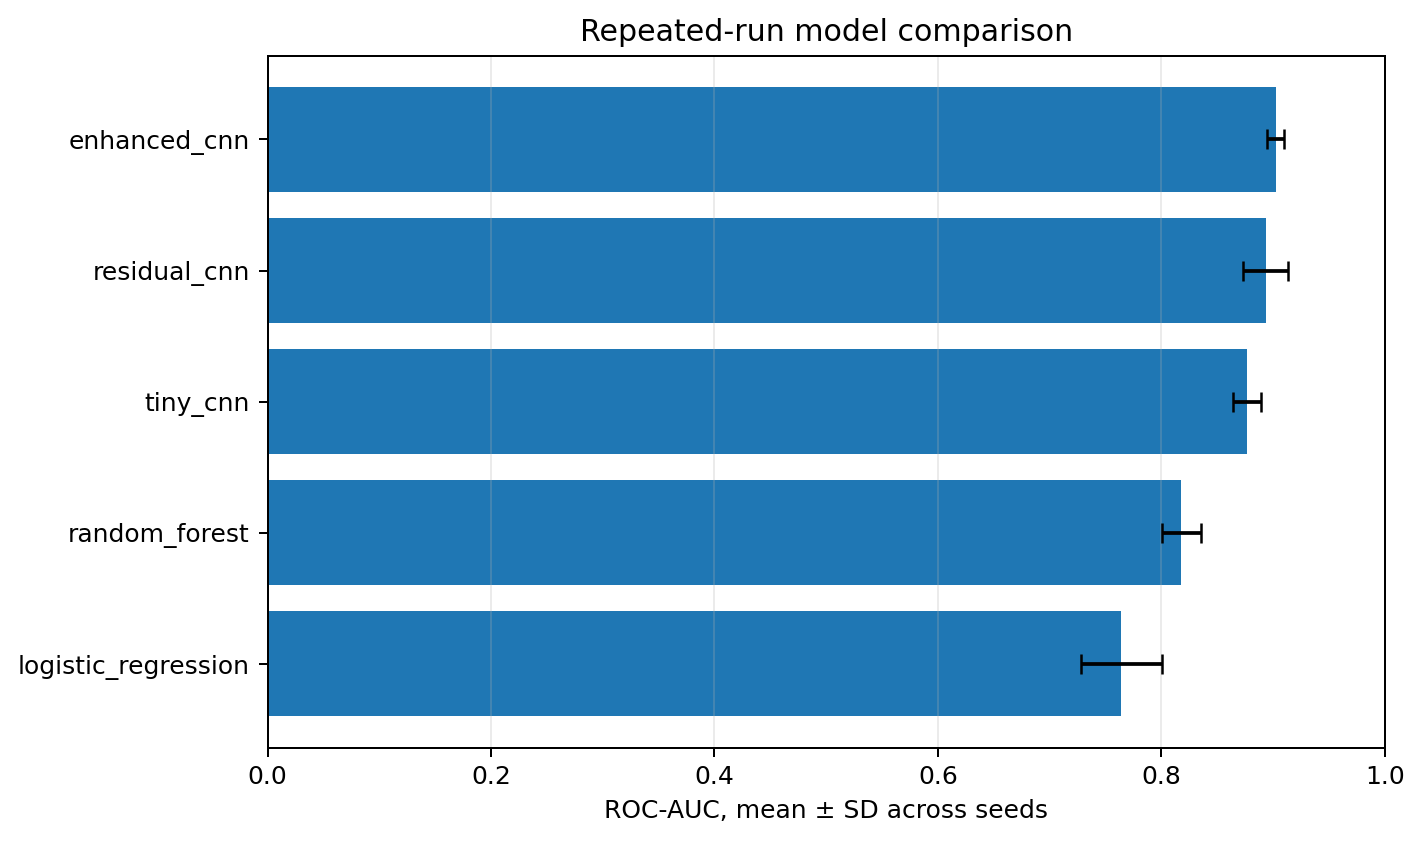

### threshold_sweep_best.png

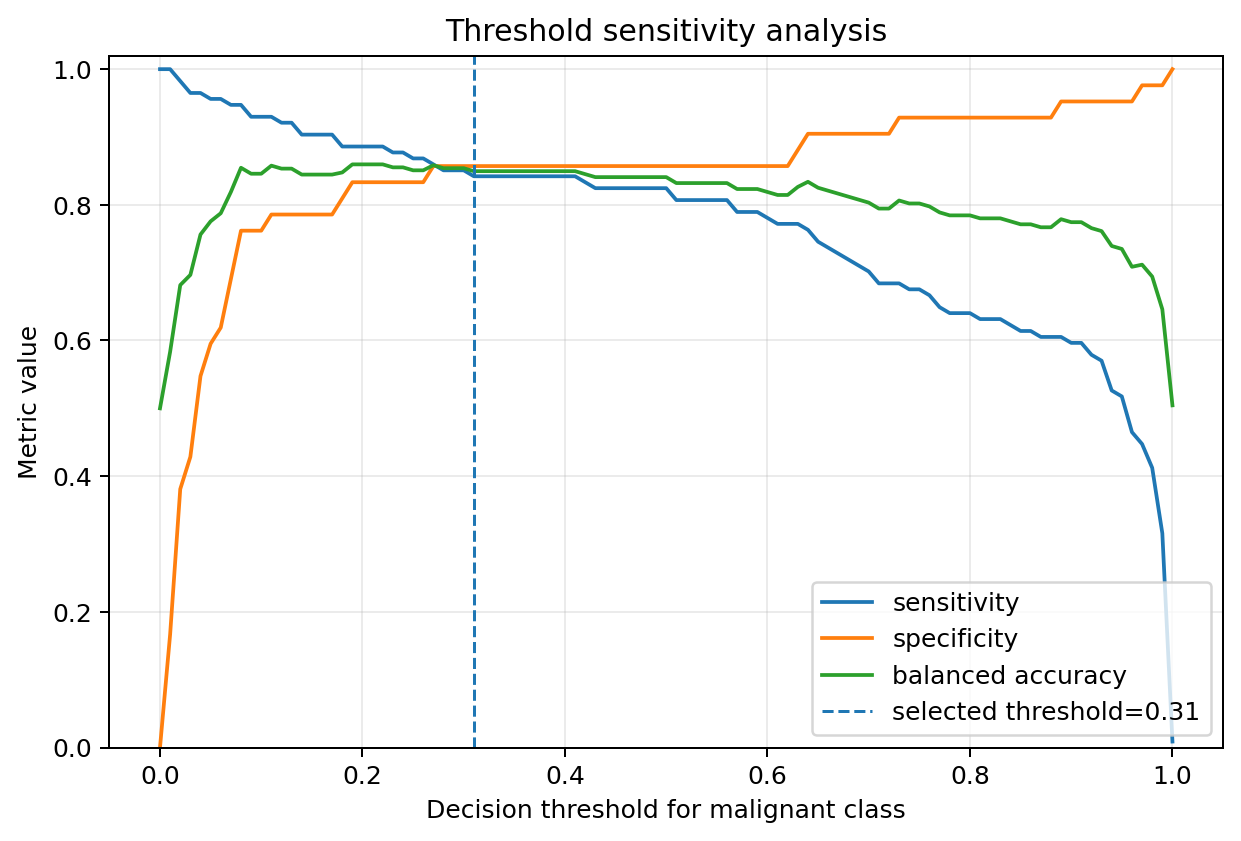

### confusion_matrix_best.png

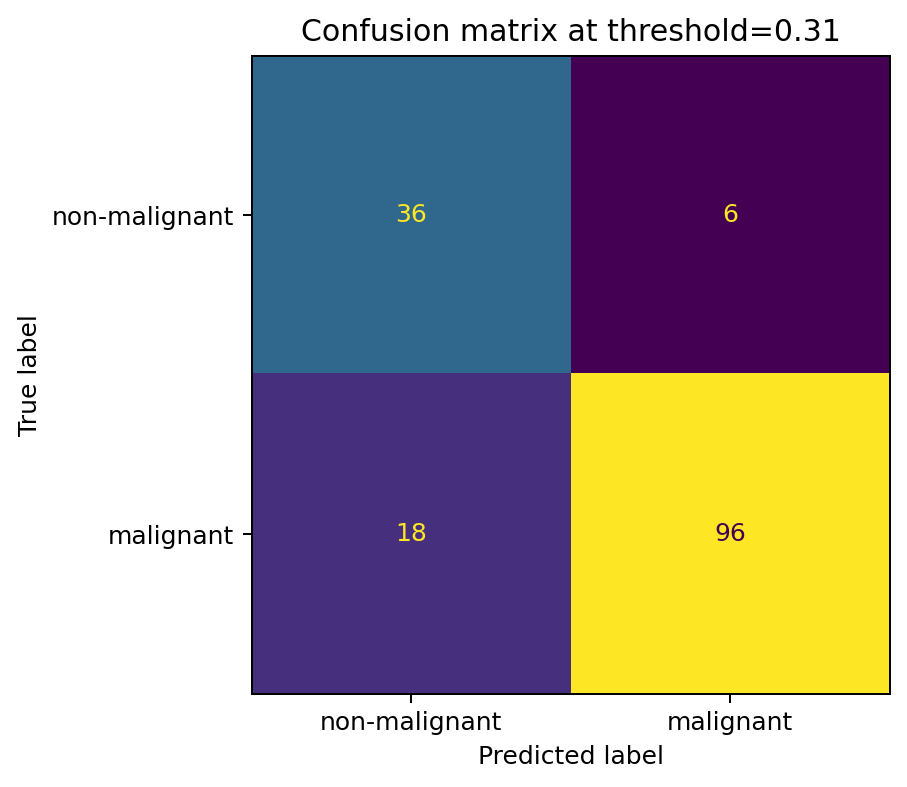

### roc_curve_best.png

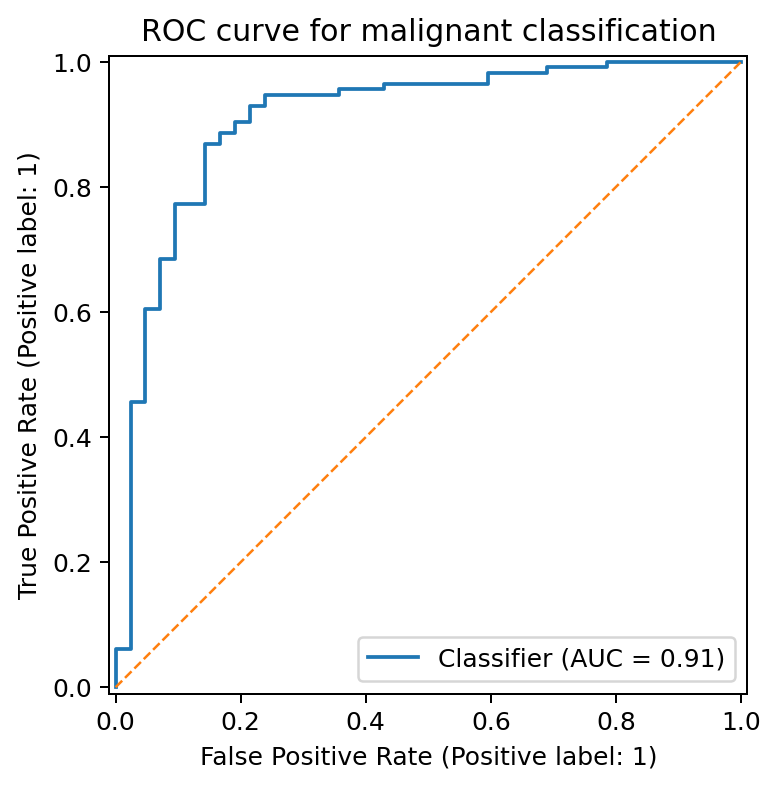

### precision_recall_curve_best.png

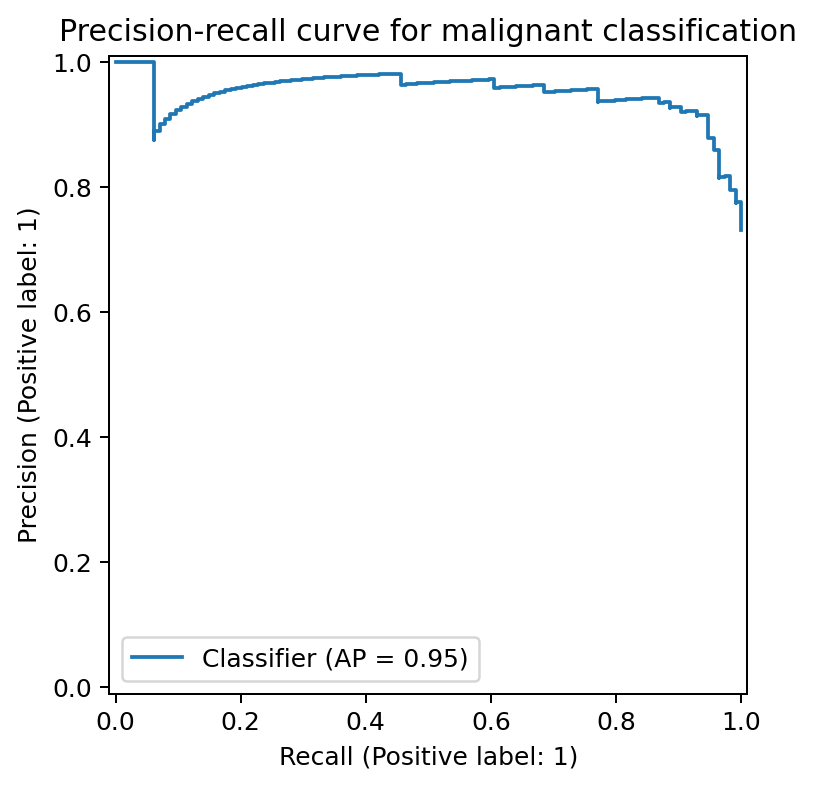

### calibration_curve_best.png

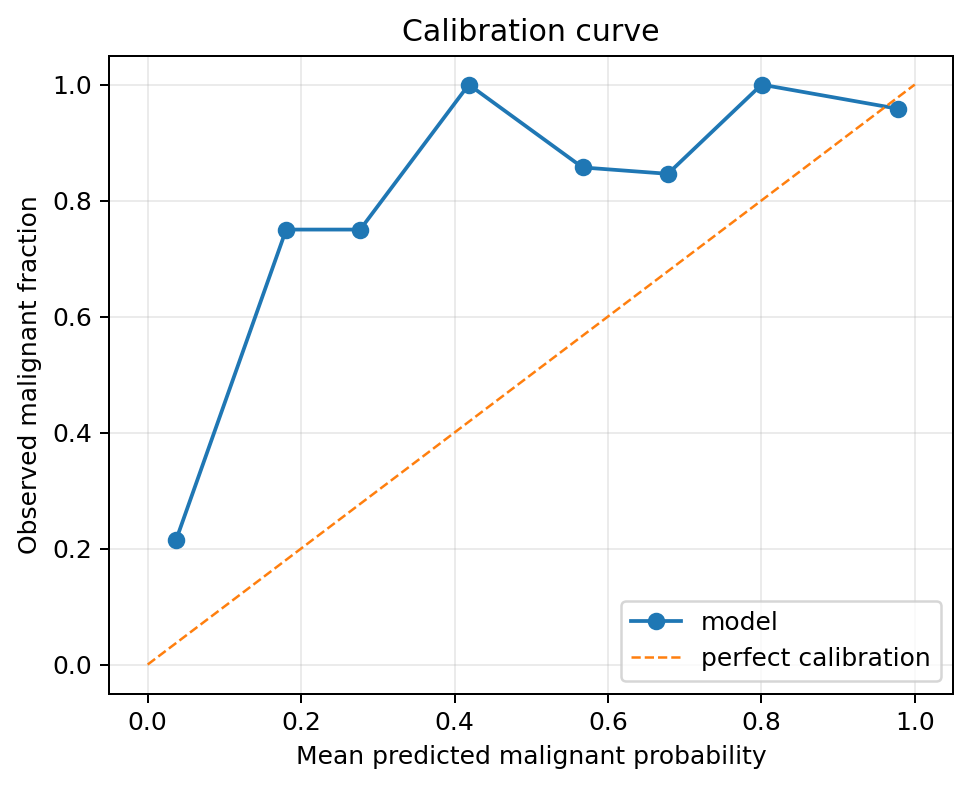

### risk_score_histogram_best.png

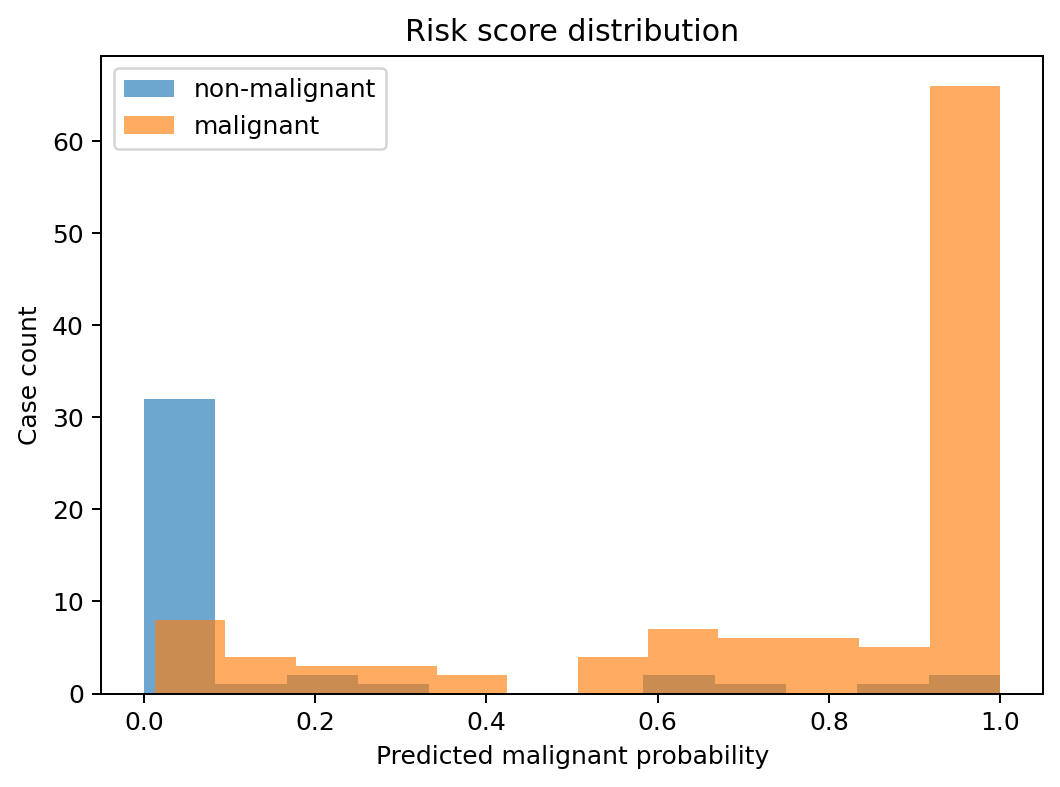

### error_gallery_best.png

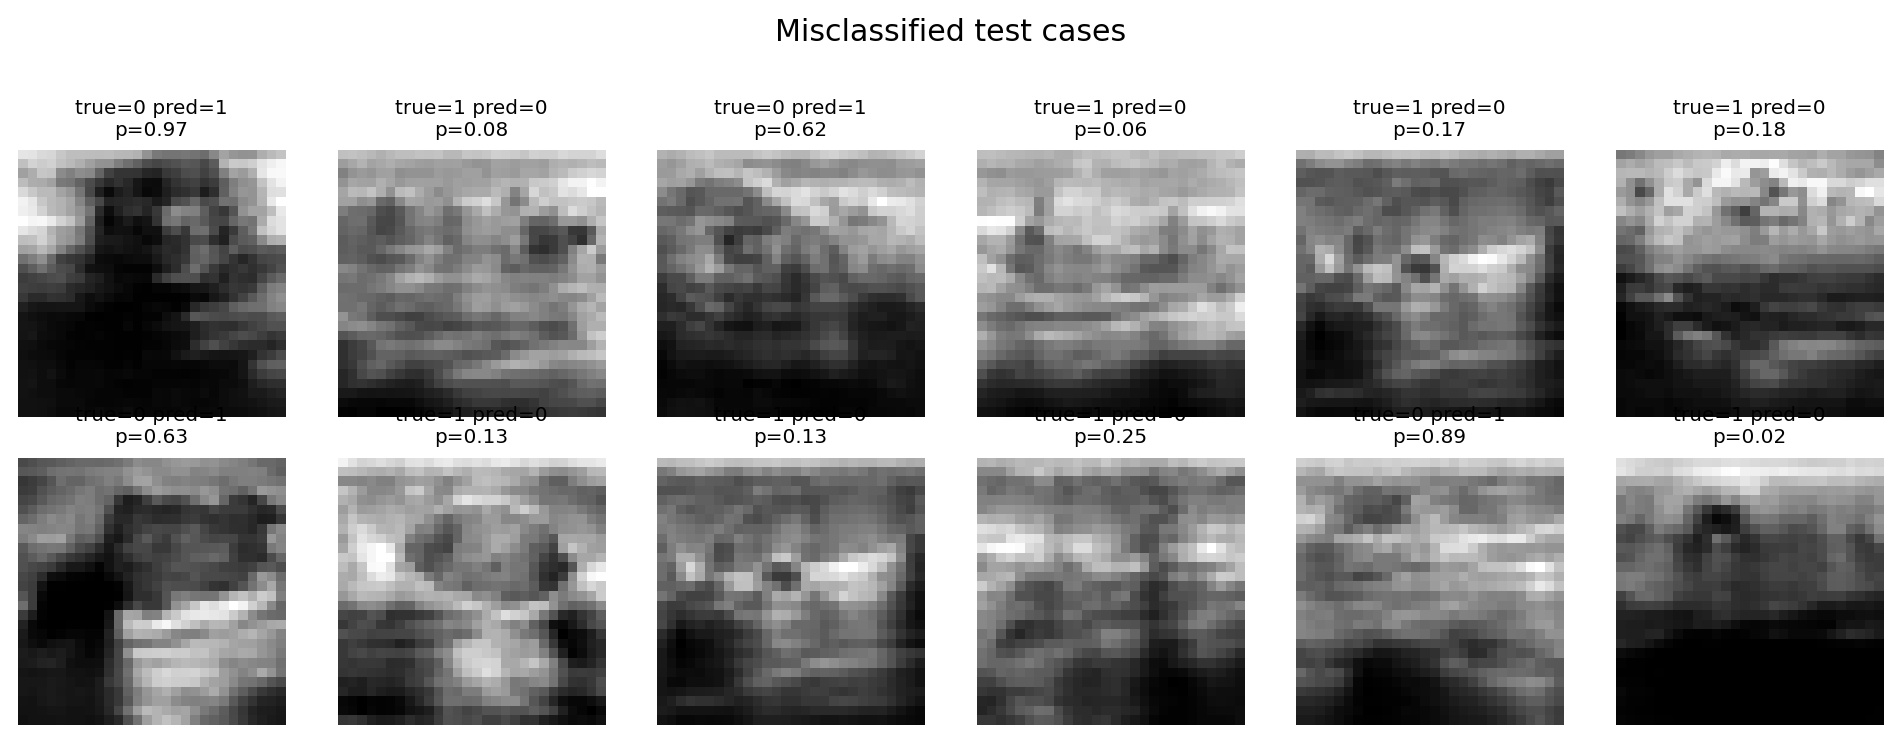

### gradcam_panel_best_cnn.png

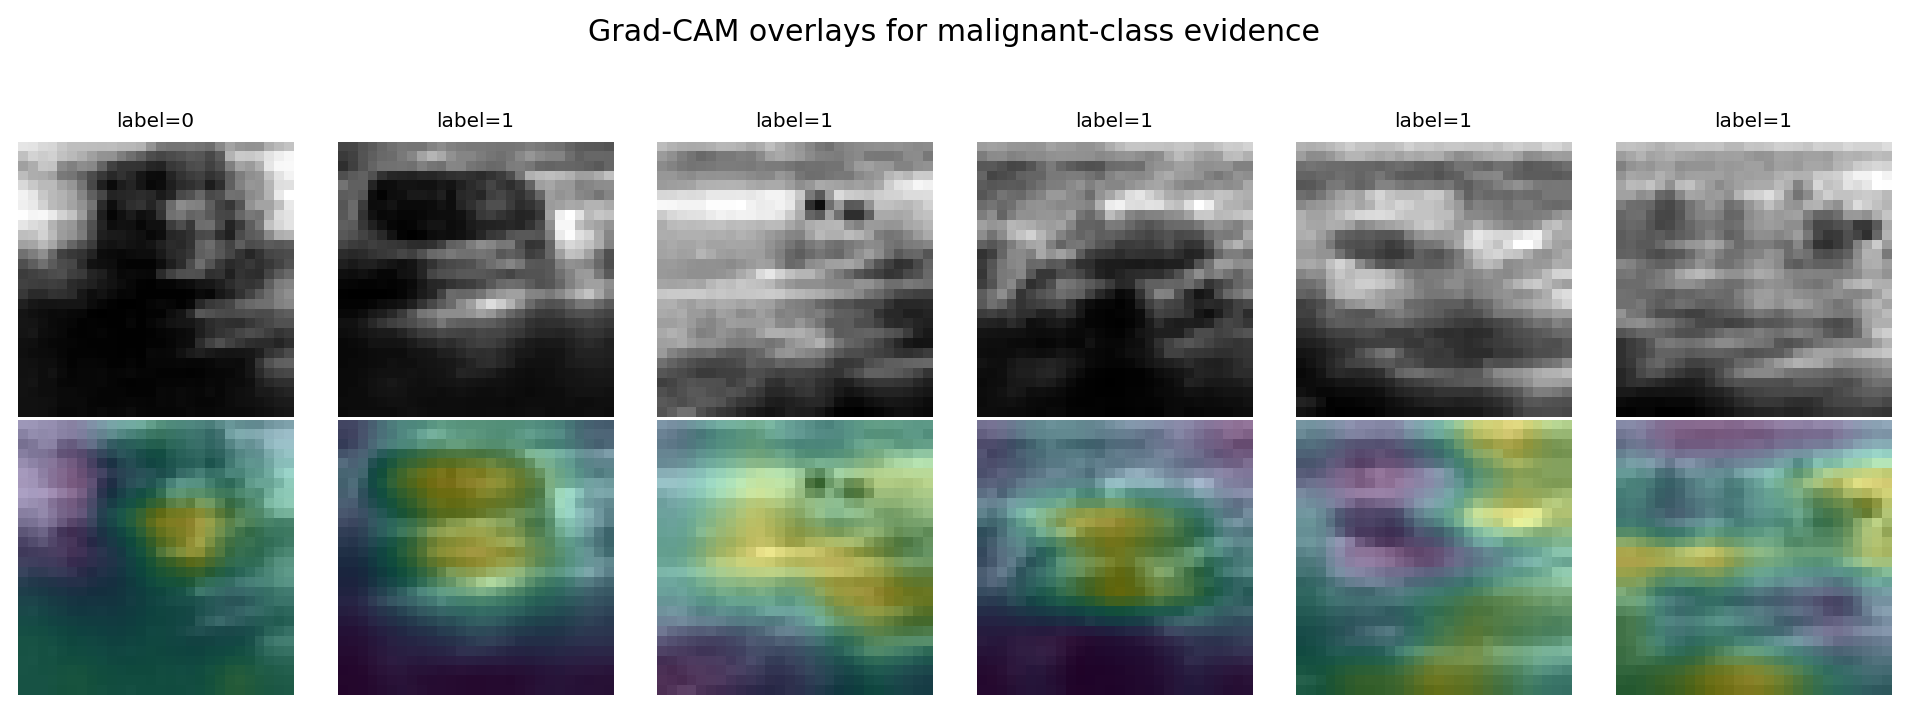

In [6]:
figure_paths = summary["figures"]
for fig_path in figure_paths:
    path = Path(fig_path)
    if path.exists() and path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        display(Markdown(f"### {path.name}"))
        display(Image(filename=str(path)))
    else:
        print("Missing or non-image artifact:", path)

## Generated written analysis

This report is created after the run from the actual metrics and figure paths. It is saved to `analysis/experiment_report.md` and printed below for convenience.

In [7]:
report_path = Path(summary["analysis_report"])
report_text = report_path.read_text(encoding="utf-8")
display(Markdown(report_text))

# Experiment Analysis: AI for Women's Health Imaging

## Study framing
This project evaluates malignant versus non-malignant classification on BreastMNIST, a standardized breast ultrasound benchmark. The emphasis is not a single pretty score; the emphasis is a reproducible evaluation loop with repeated seeds, threshold selection on validation data, classical baselines, calibration, error analysis, and interpretability artifacts.

## Dataset
- Dataset: breastmnist
- Image size: 28x28 grayscale
- Split sizes: {'train': 546, 'val': 78, 'test': 156}
- Label distributions: {'train': {'non_malignant': 147, 'malignant': 399}, 'val': {'non_malignant': 21, 'malignant': 57}, 'test': {'non_malignant': 42, 'malignant': 114}}
- Clinical note: this benchmark supports methodological exploration only. It is not a clinical diagnostic system.

## Experiment design
- Seeds: [13, 42, 101]
- Epoch budget: 200 with early stopping patience=30
- Batch size: 64
- Optimizer for CNNs: AdamW with learning rate 0.001 and weight decay 0.0001
- Decision threshold rule: selected on validation predictions, targeting sensitivity >= 0.9 when feasible
- Primary endpoint: mean ROC-AUC across repeated test runs
- Secondary endpoints: balanced accuracy, sensitivity, specificity, F1, average precision, Brier score, and expected calibration error
- Baseline comparators: class-balanced logistic regression and random forest on flattened pixels

## Repeated-run model summary
| model               |   accuracy_mean |   accuracy_std |   accuracy_min |   accuracy_max |   balanced_accuracy_mean |   balanced_accuracy_std |   balanced_accuracy_min |   balanced_accuracy_max |   roc_auc_mean |   roc_auc_std |   roc_auc_min |   roc_auc_max |   average_precision_mean |   average_precision_std |   average_precision_min |   average_precision_max |   precision_mean |   precision_std |   precision_min |   precision_max |   recall_sensitivity_mean |   recall_sensitivity_std |   recall_sensitivity_min |   recall_sensitivity_max |   specificity_mean |   specificity_std |   specificity_min |   specificity_max |   npv_mean |   npv_std |   npv_min |   npv_max |   f1_mean |     f1_std |   f1_min |   f1_max |   brier_score_mean |   brier_score_std |   brier_score_min |   brier_score_max |   ece_10_bins_mean |   ece_10_bins_std |   ece_10_bins_min |   ece_10_bins_max |   threshold_mean |   threshold_std |   threshold_min |   threshold_max |   best_epoch_mean |   best_epoch_std |   best_epoch_min |   best_epoch_max |   stopped_epoch_mean |   stopped_epoch_std |   stopped_epoch_min |   stopped_epoch_max |
|:--------------------|----------------:|---------------:|---------------:|---------------:|-------------------------:|------------------------:|------------------------:|------------------------:|---------------:|--------------:|--------------:|--------------:|-------------------------:|------------------------:|------------------------:|------------------------:|-----------------:|----------------:|----------------:|----------------:|--------------------------:|-------------------------:|-------------------------:|-------------------------:|-------------------:|------------------:|------------------:|------------------:|-----------:|----------:|----------:|----------:|----------:|-----------:|---------:|---------:|-------------------:|------------------:|------------------:|------------------:|-------------------:|------------------:|------------------:|------------------:|-----------------:|----------------:|----------------:|----------------:|------------------:|-----------------:|-----------------:|-----------------:|---------------------:|--------------------:|--------------------:|--------------------:|
| enhanced_cnn        |        0.84188  |     0.0195837  |       0.820513 |       0.858974 |                 0.834169 |              0.013516   |                0.824561 |                0.849624 |       0.902395 |    0.00770881 |      0.89411  |      0.909357 |                 0.95154  |             0.000501134 |                0.950964 |                0.951876 |         0.927297 |      0.0154099  |        0.910714 |        0.941176 |                  0.850877 |               0.040198   |                 0.815789 |                 0.894737 |           0.81746  |         0.0495635 |          0.761905 |          0.857143 |   0.67298  | 0.0514278 |  0.625    |  0.727273 |  0.886901 | 0.0168363  | 0.869159 | 0.902655 |           0.127429 |        0.00985631 |          0.116962 |          0.136532 |           0.109086 |        0.0222383  |         0.0929389 |         0.134451  |         0.436667 |        0.155349 |            0.31 |            0.61 |           38.3333 |          4.50925 |               34 |               43 |              68.3333 |             4.50925 |                  64 |                  73 |
| residual_cnn        |        0.82906  |     0.0289054  |       0.801282 |       0.858974 |                 0.827903 |              0.0235136  |                0.803885 |                0.850877 |       0.893553 |    0.0201211  |      0.874478 |      0.914578 |                 0.953177 |             0.011674    |                0.944996 |                0.966546 |         0.927949 |      0.00775808 |        0.919192 |        0.933962 |                  0.830409 |               0.0354513  |                 0.798246 |                 0.868421 |           0.825397 |         0.0137464 |          0.809524 |          0.833333 |   0.644285 | 0.0522071 |  0.596491 |  0.7      |  0.876293 | 0.0228277  | 0.85446  | 0.9      |           0.153981 |        0.00963778 |          0.145581 |          0.164503 |           0.149513 |        0.0256192  |         0.131611  |         0.178859  |         0.326667 |        0.23029  |            0.13 |            0.58 |           39      |          7.2111  |               33 |               47 |              69      |             7.2111  |                  63 |                  77 |
| tiny_cnn            |        0.831197 |     0.0185048  |       0.820513 |       0.852564 |                 0.794277 |              0.0341138  |                0.764411 |                0.831454 |       0.876462 |    0.0122154  |      0.862782 |      0.886278 |                 0.941613 |             0.00360676  |                0.938743 |                0.945662 |         0.89301  |      0.0234415  |        0.87069  |        0.917431 |                  0.874269 |               0.0133993  |                 0.859649 |                 0.885965 |           0.714286 |         0.0714286 |          0.642857 |          0.785714 |   0.676434 | 0.0250077 |  0.652174 |  0.702128 |  0.883374 | 0.0117934  | 0.875    | 0.896861 |           0.135933 |        0.0206604  |          0.12147  |          0.159595 |           0.114853 |        0.0256774  |         0.0902899 |         0.141516  |         0.443333 |        0.105987 |            0.33 |            0.54 |           49.3333 |          1.52753 |               48 |               51 |              79.3333 |             1.52753 |                  78 |                  81 |
| random_forest       |        0.816239 |     0.00740193 |       0.807692 |       0.820513 |                 0.728906 |              0.00940546 |                0.718045 |                0.734336 |       0.817808 |    0.0175368  |      0.805764 |      0.837928 |                 0.910412 |             0.0125292   |                0.898381 |                0.923386 |         0.844086 |      0.00465605 |        0.83871  |        0.846774 |                  0.918129 |               0.00506448 |                 0.912281 |                 0.921053 |           0.539683 |         0.0137464 |          0.52381  |          0.547619 |   0.708333 | 0.0180422 |  0.6875   |  0.71875  |  0.879552 | 0.00485168 | 0.87395  | 0.882353 |           0.141304 |        0.00443317 |          0.136782 |          0.145642 |           0.064244 |        0.00897037 |         0.0580891 |         0.0745364 |         0.58     |        0        |            0.58 |            0.58 |          nan      |        nan       |              nan |              nan |             nan      |           nan       |                 nan |                 nan |
| logistic_regression |        0.754274 |     0.00979183 |       0.74359  |       0.762821 |                 0.678989 |              0.036267   |                0.645363 |                0.717419 |       0.764063 |    0.0361533  |      0.723475 |      0.792815 |                 0.905129 |             0.0159581   |                0.887388 |                0.918313 |         0.826453 |      0.0258638  |        0.801587 |        0.853211 |                  0.842105 |               0.038236   |                 0.815789 |                 0.885965 |           0.515873 |         0.107363  |          0.404762 |          0.619048 |   0.547889 | 0.021915  |  0.52381  |  0.566667 |  0.833436 | 0.00857082 | 0.824561 | 0.841667 |           0.208325 |        0.0181809  |          0.191115 |          0.227342 |           0.184    |        0.0248469  |         0.15542   |         0.200474  |         0.436667 |        0.215716 |            0.19 |            0.59 |          nan      |        nan       |              nan |              nan |             nan      |           nan       |                 nan |                 nan |

## Per-run metrics
|   accuracy |   balanced_accuracy |   roc_auc |   average_precision |   precision |   recall_sensitivity |   specificity |      npv |       f1 |   brier_score |   ece_10_bins |   threshold |   tn |   fp |   fn |   tp |   auc_ci_low |   auc_ci_high | model               |   seed |   best_epoch |   stopped_epoch |   best_val_loss | threshold_rule                                  | model_family   |
|-----------:|--------------------:|----------:|--------------------:|------------:|---------------------:|--------------:|---------:|---------:|--------------:|--------------:|------------:|-----:|-----:|-----:|-----:|-------------:|--------------:|:--------------------|-------:|-------------:|----------------:|----------------:|:------------------------------------------------|:---------------|
|   0.858974 |            0.850877 |  0.914578 |            0.966546 |    0.933962 |             0.868421 |      0.833333 | 0.7      | 0.9      |      0.164503 |     0.178859  |        0.13 |   35 |    7 |   15 |   99 |     0.86208  |      0.957978 | residual_cnn        |     42 |           47 |              77 |        0.323319 | max_specificity_given_sensitivity_at_least_0.90 | cnn            |
|   0.846154 |            0.849624 |  0.909357 |            0.950964 |    0.941176 |             0.842105 |      0.857143 | 0.666667 | 0.888889 |      0.136532 |     0.134451  |        0.31 |   36 |    6 |   18 |   96 |     0.848106 |      0.958912 | enhanced_cnn        |     13 |           38 |              68 |        0.245668 | max_specificity_given_sensitivity_at_least_0.90 | cnn            |
|   0.858974 |            0.828321 |  0.903718 |            0.951876 |    0.910714 |             0.894737 |      0.761905 | 0.727273 | 0.902655 |      0.116962 |     0.0929389 |        0.39 |   32 |   10 |   12 |  102 |     0.836031 |      0.954804 | enhanced_cnn        |     42 |           34 |              64 |        0.262183 | max_specificity_given_sensitivity_at_least_0.90 | cnn            |
|   0.820513 |            0.824561 |  0.89411  |            0.951781 |    0.93     |             0.815789 |      0.833333 | 0.625    | 0.869159 |      0.128794 |     0.0998691 |        0.61 |   35 |    7 |   21 |   93 |     0.835813 |      0.946188 | enhanced_cnn        |    101 |           43 |              73 |        0.298281 | max_specificity_given_sensitivity_at_least_0.90 | cnn            |
|   0.826923 |            0.828947 |  0.891604 |            0.944996 |    0.930693 |             0.824561 |      0.833333 | 0.636364 | 0.874419 |      0.145581 |     0.138068  |        0.27 |   35 |    7 |   20 |   94 |     0.82731  |      0.945441 | residual_cnn        |    101 |           33 |              63 |        0.295308 | max_specificity_given_sensitivity_at_least_0.90 | cnn            |
|   0.852564 |            0.831454 |  0.886278 |            0.940435 |    0.917431 |             0.877193 |      0.785714 | 0.702128 | 0.896861 |      0.12147  |     0.112753  |        0.54 |   33 |    9 |   14 |  100 |     0.813682 |      0.94529  | tiny_cnn            |     42 |           51 |              81 |        0.26577  | max_specificity_given_sensitivity_at_least_0.90 | cnn            |
|   0.820513 |            0.764411 |  0.880326 |            0.945662 |    0.87069  |             0.885965 |      0.642857 | 0.675    | 0.878261 |      0.126733 |     0.0902899 |        0.46 |   27 |   15 |   13 |  101 |     0.810386 |      0.936186 | tiny_cnn            |    101 |           48 |              78 |        0.233532 | max_specificity_given_sensitivity_at_least_0.90 | cnn            |
|   0.801282 |            0.803885 |  0.874478 |            0.947989 |    0.919192 |             0.798246 |      0.809524 | 0.596491 | 0.85446  |      0.151858 |     0.131611  |        0.58 |   34 |    8 |   23 |   91 |     0.811025 |      0.931549 | residual_cnn        |     13 |           37 |              67 |        0.332568 | max_specificity_given_sensitivity_at_least_0.90 | cnn            |
|   0.820513 |            0.786967 |  0.862782 |            0.938743 |    0.890909 |             0.859649 |      0.714286 | 0.652174 | 0.875    |      0.159595 |     0.141516  |        0.33 |   30 |   12 |   16 |   98 |     0.790984 |      0.924901 | tiny_cnn            |     13 |           49 |              79 |        0.3388   | max_specificity_given_sensitivity_at_least_0.90 | cnn            |
|   0.820513 |            0.734336 |  0.837928 |            0.923386 |    0.846774 |             0.921053 |      0.547619 | 0.71875  | 0.882353 |      0.136782 |     0.0745364 |        0.58 |   23 |   19 |    9 |  105 |     0.758459 |      0.909299 | random_forest       |     13 |          nan |             nan |      nan        | max_specificity_given_sensitivity_at_least_0.90 | classical_ml   |
|   0.807692 |            0.718045 |  0.809733 |            0.898381 |    0.83871  |             0.912281 |      0.52381  | 0.6875   | 0.87395  |      0.141488 |     0.0580891 |        0.58 |   22 |   20 |   10 |  104 |     0.723615 |      0.883879 | random_forest       |    101 |          nan |             nan |      nan        | max_specificity_given_sensitivity_at_least_0.90 | classical_ml   |
|   0.820513 |            0.734336 |  0.805764 |            0.909469 |    0.846774 |             0.921053 |      0.547619 | 0.71875  | 0.882353 |      0.145642 |     0.0601065 |        0.58 |   23 |   19 |    9 |  105 |     0.721319 |      0.882907 | random_forest       |     42 |          nan |             nan |      nan        | max_specificity_given_sensitivity_at_least_0.90 | classical_ml   |
|   0.762821 |            0.717419 |  0.792815 |            0.918313 |    0.853211 |             0.815789 |      0.619048 | 0.553191 | 0.834081 |      0.191115 |     0.15542   |        0.53 |   26 |   16 |   21 |   93 |     0.716885 |      0.861308 | logistic_regression |     13 |          nan |             nan |      nan        | max_specificity_given_sensitivity_at_least_0.90 | classical_ml   |
|   0.75641  |            0.645363 |  0.775898 |            0.909687 |    0.801587 |             0.885965 |      0.404762 | 0.566667 | 0.841667 |      0.206517 |     0.196106  |        0.19 |   17 |   25 |   13 |  101 |     0.69757  |      0.844115 | logistic_regression |     42 |          nan |             nan |      nan        | max_specificity_given_sensitivity_at_least_0.90 | classical_ml   |
|   0.74359  |            0.674185 |  0.723475 |            0.887388 |    0.824561 |             0.824561 |      0.52381  | 0.52381  | 0.824561 |      0.227342 |     0.200474  |        0.59 |   22 |   20 |   20 |   94 |     0.63793  |      0.803365 | logistic_regression |    101 |          nan |             nan |      nan        | max_specificity_given_sensitivity_at_least_0.90 | classical_ml   |

## Main finding
The strongest aggregate model was **enhanced_cnn**, with mean ROC-AUC=0.902 ± 0.008 and mean balanced accuracy=0.834 across seeds.
The representative best run used seed 13, threshold=0.31, ROC-AUC=0.909, sensitivity=0.842, and specificity=0.857.

## Interpretation
The validation-selected threshold makes the test evaluation cleaner than tuning directly on test labels. The threshold sweep should be read as an operating-point analysis, not as a license to cherry-pick. A high ROC-AUC indicates useful ranking behavior, while sensitivity, specificity, calibration, and error-gallery behavior decide whether the model is practically attractive for any downstream workflow.

Grad-CAM panels are included for qualitative auditing of CNN attention patterns. They are useful smoke signals, not proof of causal reasoning or clinical correctness.

## Limitations
- BreastMNIST is deliberately low-resolution, which makes it ideal for reproducible benchmarking but less representative of full-resolution ultrasound review.
- Dataset size is modest, so repeated seeds and confidence intervals matter more than a single headline score.
- The binary formulation merges normal and benign into non-malignant, which is appropriate for this benchmark but not a complete clinical taxonomy.
- No patient-level external validation is performed in this notebook.
- This repository should be presented as a benchmark research prototype, not a deployed diagnostic system.

## Saved figures
- `/content/drive/MyDrive/repo_polished/figures/dataset_examples.png`
- `/content/drive/MyDrive/repo_polished/figures/training_curves_tiny_cnn_seed13.png`
- `/content/drive/MyDrive/repo_polished/figures/training_curves_enhanced_cnn_seed13.png`
- `/content/drive/MyDrive/repo_polished/figures/training_curves_residual_cnn_seed13.png`
- `/content/drive/MyDrive/repo_polished/figures/training_curves_tiny_cnn_seed42.png`
- `/content/drive/MyDrive/repo_polished/figures/training_curves_enhanced_cnn_seed42.png`
- `/content/drive/MyDrive/repo_polished/figures/training_curves_residual_cnn_seed42.png`
- `/content/drive/MyDrive/repo_polished/figures/training_curves_tiny_cnn_seed101.png`
- `/content/drive/MyDrive/repo_polished/figures/training_curves_enhanced_cnn_seed101.png`
- `/content/drive/MyDrive/repo_polished/figures/training_curves_residual_cnn_seed101.png`
- `/content/drive/MyDrive/repo_polished/figures/experiment_metric_table.png`
- `/content/drive/MyDrive/repo_polished/figures/repeated_metric_summary.png`
- `/content/drive/MyDrive/repo_polished/figures/threshold_sweep_best.png`
- `/content/drive/MyDrive/repo_polished/figures/confusion_matrix_best.png`
- `/content/drive/MyDrive/repo_polished/figures/roc_curve_best.png`
- `/content/drive/MyDrive/repo_polished/figures/precision_recall_curve_best.png`
- `/content/drive/MyDrive/repo_polished/figures/calibration_curve_best.png`
- `/content/drive/MyDrive/repo_polished/figures/risk_score_histogram_best.png`
- `/content/drive/MyDrive/repo_polished/figures/error_gallery_best.png`
- `/content/drive/MyDrive/repo_polished/figures/gradcam_panel_best_cnn.png`

## Reproducibility notes
All tables, predictions, figures, model checkpoints, and this analysis file are generated by the notebook and written to the repository folders. Re-running the notebook refreshes the artifacts with the current execution outputs.


## Artifact audit

This cell verifies that expected folders are populated after running the notebook.

In [8]:
expected_files = [
    PROJECT_ROOT / "results" / "metrics.csv",
    PROJECT_ROOT / "results" / "metrics_by_run.csv",
    PROJECT_ROOT / "results" / "metrics_summary_by_model.csv",
    PROJECT_ROOT / "results" / "predictions_test.csv",
    PROJECT_ROOT / "results" / "predictions_validation.csv",
    PROJECT_ROOT / "results" / "threshold_sweep_best.csv",
    PROJECT_ROOT / "results" / "experiment_summary.json",
    PROJECT_ROOT / "analysis" / "experiment_report.md",
    PROJECT_ROOT / "figures" / "repeated_metric_summary.png",
    PROJECT_ROOT / "figures" / "threshold_sweep_best.png",
    PROJECT_ROOT / "figures" / "roc_curve_best.png",
    PROJECT_ROOT / "figures" / "confusion_matrix_best.png",
    PROJECT_ROOT / "figures" / "gradcam_panel_best_cnn.png",
]

print("Artifact audit:")
for path in expected_files:
    status = "OK" if path.exists() and path.stat().st_size > 0 else "MISSING"
    print(f"{status:8s} {path.relative_to(PROJECT_ROOT)}")

print("\nresults/ contents:")
for path in sorted((PROJECT_ROOT / "results").glob("**/*")):
    if path.is_file():
        print(" -", path.relative_to(PROJECT_ROOT), f"({path.stat().st_size} bytes)")

print("\nfigures/ contents:")
for path in sorted((PROJECT_ROOT / "figures").glob("*")):
    if path.is_file():
        print(" -", path.relative_to(PROJECT_ROOT), f"({path.stat().st_size} bytes)")

print("\nanalysis/ contents:")
for path in sorted((PROJECT_ROOT / "analysis").glob("*")):
    if path.is_file():
        print(" -", path.relative_to(PROJECT_ROOT), f"({path.stat().st_size} bytes)")


Artifact audit:
OK       results/metrics.csv
OK       results/metrics_by_run.csv
OK       results/metrics_summary_by_model.csv
OK       results/predictions_test.csv
OK       results/predictions_validation.csv
OK       results/threshold_sweep_best.csv
OK       results/experiment_summary.json
OK       analysis/experiment_report.md
OK       figures/repeated_metric_summary.png
OK       figures/threshold_sweep_best.png
OK       figures/roc_curve_best.png
OK       figures/confusion_matrix_best.png
OK       figures/gradcam_panel_best_cnn.png

results/ contents:
 - results/.gitkeep (0 bytes)
 - results/config.json (448 bytes)
 - results/dataset_summary.json (381 bytes)
 - results/dataset_summary_preview.json (381 bytes)
 - results/experiment_summary.json (3363 bytes)
 - results/history_enhanced_cnn_seed101.csv (8725 bytes)
 - results/history_enhanced_cnn_seed13.csv (8056 bytes)
 - results/history_enhanced_cnn_seed42.csv (7599 bytes)
 - results/history_residual_cnn_seed101.csv (7545 bytes)
 - r

## Reproducibility note

The default configuration uses a 200-epoch budget with early stopping, three seeds, class weighting, validation-selected thresholds, and multiple baselines. The saved outputs are refreshed every time the notebook is rerun.